<a href="https://colab.research.google.com/github/BNagaraj2004/codealpha_projects-/blob/main/codealpha_smallproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
url = "https://books.toscrape.com/catalogue/page-1.html"
response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")
books = soup.find_all("article", class_="product_pod")


In [ ]:
data = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text.replace("£", "")
    rating = book.p["class"][1]
    availability = book.find("p", class_="instock availability").text.strip()

    data.append([title, price, rating, availability])


In [ ]:
df = pd.DataFrame(
    data,
    columns=["Title", "Price", "Rating", "Availability"]
)

df


,Title,Price,Rating,Availability
0,A Light in the Attic,Â51.77,Three,In stock
1,Tipping the Velvet,Â53.74,One,In stock
2,Soumission,Â50.10,One,In stock
3,Sharp Objects,Â47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â54.23,Five,In stock
5,The Requiem Red,Â22.65,One,In stock
6,The Dirty Little Secrets of Getting Your Dream...,Â33.34,Four,In stock
7,The Coming Woman: A Novel Based on the Life of...,Â17.93,Three,In stock
8,The Boys in the Boat: Nine Americans and Their...,Â22.60,Four,In stock
9,The Black Maria,Â52.15,One,In stock


In [ ]:
df.to_csv("books_data.csv", index=False)


In [ ]:
df.head()


,Title,Price,Rating,Availability
0,A Light in the Attic,Â51.77,Three,In stock
1,Tipping the Velvet,Â53.74,One,In stock
2,Soumission,Â50.10,One,In stock
3,Sharp Objects,Â47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â54.23,Five,In stock


In [ ]:
df.shape


(20, 4)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         20 non-null     object
 1   Price         20 non-null     object
 2   Rating        20 non-null     object
 3   Availability  20 non-null     object
dtypes: object(4)
memory usage: 772.0+ bytes


In [ ]:
df["Price"] = df["Price"].str.replace("[^0-9.]", "", regex=True)


In [ ]:
df["Price"] = df["Price"].astype(float)


In [ ]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)


In [ ]:
df


,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock
5,The Requiem Red,22.65,1,In stock
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,In stock
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,In stock
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,In stock
9,The Black Maria,52.15,1,In stock


In [ ]:
df.describe()


,Price,Rating
count,20.000000,20.000000
mean,38.048500,2.850000
std,15.135231,1.565248
min,13.990000,1.000000
25%,22.637500,1.000000
50%,41.380000,3.000000
75%,51.865000,4.000000
max,57.250000,5.000000


In [ ]:
EDA QUESTIONS:
1. What is the average price of books?
2. Which rating appears most frequently?
3. Does a higher rating imply a higher price?


In [ ]:
df["Price"].mean()


np.float64(38.048500000000004)

In [ ]:
df["Rating"].value_counts()


,count
Rating,
1,6
5,4
4,4
3,3
2,3


In [ ]:
df.groupby("Rating")["Price"].mean()


,Price
Rating,
1,40.018333
2,36.830000
3,42.316667
4,31.105000
5,39.750000


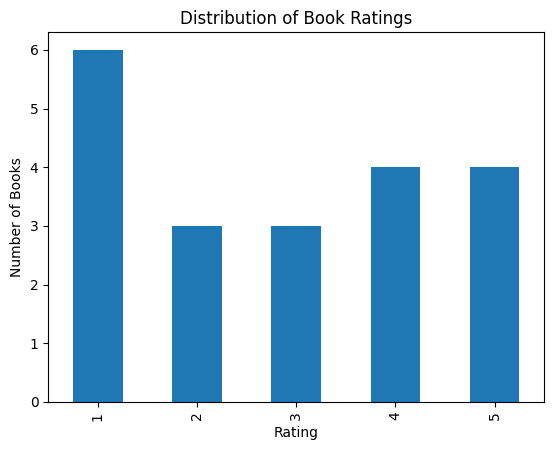

In [ ]:
df["Rating"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Ratings")
plt.show()


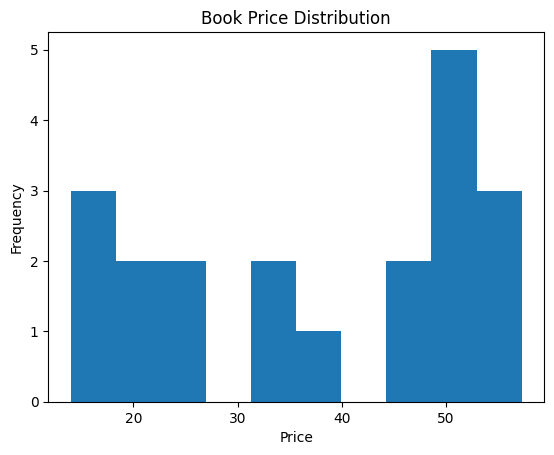

In [ ]:
plt.hist(df["Price"], bins=10)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Book Price Distribution")
plt.show()


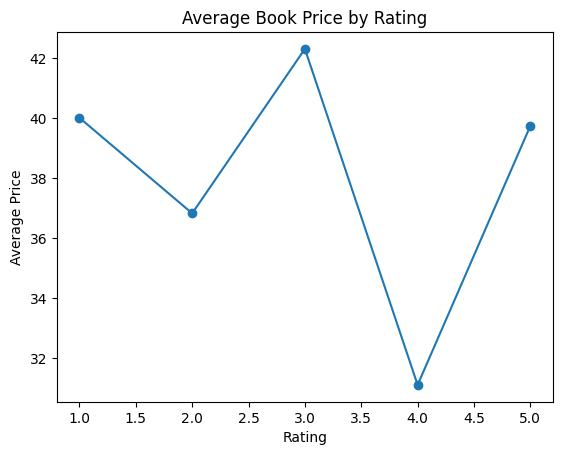

In [ ]:
df.groupby("Rating")["Price"].mean().plot(kind="line", marker="o")
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.title("Average Book Price by Rating")
plt.show()
